In [ ]:
!pip install -q pytorch-msssim==0.2.1 tqdm timm


In [ ]:
import os
import numpy as np
from pathlib import Path
from glob import glob
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pytorch_msssim import ssim as ssim_torch

# SET CORRECT PATH TO YOUR FINAL DATA
BASE = Path("/content/drive/MyDrive/brain_tumor_project")
DATA_DIR = BASE / "data" / "final"

# Where to save enhancement model
SAVE_DIR = BASE / "models" / "enhancement"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Where to save enhanced images
ENHANCED_OUT = BASE / "data" / "enhanced"
ENHANCED_OUT.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE =", DEVICE)


DEVICE = cpu


In [ ]:
class EnhancementDataset(Dataset):
    def __init__(self, root, split="train", img_size=224, noise_std=0.08):
        self.img_size = img_size
        self.noise_std = noise_std
        self.files = []

        base = f"{root}/{split}/images"

        for cls in os.listdir(base):            # '1', '2', '3', 'no_tumor'
            folder = f"{base}/{cls}"
            for f in os.listdir(folder):
                self.files.append({
                    "path": f"{folder}/{f}",
                    "name": f,
                    "cls": cls                  # SAVE CLASS HERE
                })

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        info = self.files[idx]

        img = cv2.imread(info["path"], 0)
        img = cv2.resize(img, (self.img_size, self.img_size))
        img = img.astype(np.float32) / 255.0

        clean = torch.tensor(img).unsqueeze(0)
        noisy = clean + torch.randn_like(clean) * self.noise_std

        return noisy, clean, info["name"], info["cls"]


In [ ]:
# -----------------------------
# LOSS = α*(1-SSIM) + (1-α)*L1
# -----------------------------

def enhancement_loss(pred, target, alpha=0.84):
    # AMP makes pred float16 → SSIM requires float32
    pred_32 = pred.float()
    target_32 = target.float()

    # pixel loss (L1) – safe in mixed precision
    l1 = F.l1_loss(pred, target)

    # SSIM expects all float32
    ssim_val = ssim_torch(pred_32, target_32, data_range=1.0)

    loss = alpha * (1 - ssim_val) + (1 - alpha) * l1

    return loss, l1.item(), float(ssim_val.item())



In [ ]:
from skimage.metrics import peak_signal_noise_ratio as psnr_sk
from skimage.metrics import structural_similarity as ssim_sk

def to_numpy(t):
    arr = t.detach().cpu().squeeze().numpy()
    arr = (arr * 255).astype(np.uint8)
    return arr

def compute_metrics(pred, target):
    psnrs, ssims = [], []
    for i in range(pred.shape[0]):
        p = to_numpy(pred[i])
        t = to_numpy(target[i])
        psnrs.append(psnr_sk(t, p, data_range=255))
        ssims.append(ssim_sk(t, p, data_range=255))
    return np.mean(psnrs), np.mean(ssims)


In [ ]:
# ------------------------------------
# CREATE DATALOADERS
# ------------------------------------

train_ds = EnhancementDataset(DATA_DIR, split="train", img_size=224, noise_std=0.08)
val_ds   = EnhancementDataset(DATA_DIR, split="val",   img_size=224, noise_std=0.08)
test_ds  = EnhancementDataset(DATA_DIR, split="test",  img_size=224, noise_std=0.08)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=0)

print("Train images:", len(train_ds))
print("Val images:  ", len(val_ds))
print("Test images: ", len(test_ds))


Train images: 2213
Val images:   635
Test images:  314


In [ ]:
# ---------------------------
# U-NET MODEL FOR ENHANCEMENT
# ---------------------------

import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNetSmall(nn.Module):
    def __init__(self, in_ch=1):
        super().__init__()
        self.down1 = DoubleConv(in_ch, 64)
        self.pool = nn.MaxPool2d(2)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.out_conv = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        c1 = self.down1(x)
        p1 = self.pool(c1)

        c2 = self.down2(p1)
        p2 = self.pool(c2)

        c3 = self.down3(p2)

        u2 = self.up2(c3)
        u2 = torch.cat([u2, c2], dim=1)
        c4 = self.conv2(u2)

        u1 = self.up1(c4)
        u1 = torch.cat([u1, c1], dim=1)
        c5 = self.conv1(u1)

        out = torch.sigmoid(self.out_conv(c5))
        return out


In [ ]:
# --------------------------------------
# OPTIMIZED TRAINING LOOP FOR U-NET
# (AMP + GPU + faster)
# --------------------------------------

def train_unet(model, train_loader, val_loader, epochs=60, lr=5e-5, patience=7):

    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = torch.cuda.amp.GradScaler()

    best_ssim = -1
    no_improve = 0

    for epoch in range(1, epochs+1):
        model.train()
        total_loss = 0

        for noisy, clean, _ in train_loader:
            noisy = noisy.to(DEVICE)
            clean = clean.to(DEVICE)

            opt.zero_grad()

            with torch.cuda.amp.autocast():
                pred = model(noisy)
                loss, _, _ = enhancement_loss(pred, clean)

            scaler.scale(loss).backward()

            # -----------------------------
            # GRADIENT CLIPPING (IMPORTANT)
            # -----------------------------
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            scaler.step(opt)
            scaler.update()

            total_loss += loss.item()

        # ---------------- VALIDATION ----------------
        model.eval()
        psnr_val, ssim_val = 0, 0
        count = 0

        with torch.no_grad():
            for noisy, clean, _ in val_loader:
                noisy = noisy.to(DEVICE)
                clean = clean.to(DEVICE)
                pred = model(noisy)

                p, s = compute_metrics(pred, clean)
                psnr_val += p
                ssim_val += s
                count += 1

        psnr_val /= count
        ssim_val /= count

        print(f"Epoch {epoch}/{epochs} | Loss={total_loss/len(train_loader):.4f} | "
              f"PSNR={psnr_val:.3f} | SSIM={ssim_val:.4f}")

        # Save BEST
        if ssim_val > best_ssim:
            best_ssim = ssim_val
            no_improve = 0
            torch.save(model.state_dict(), SAVE_DIR / "unet_best.pth")
            print("✓ Saved BEST model")
        else:
            no_improve += 1

        # ---------------- EARLY STOPPING ----------------
        if no_improve >= patience:
            print(f"⛔ Early stopping triggered at epoch {epoch}")
            break

    print("Training finished.")
    return model


In [ ]:
unet = UNetSmall(in_ch=1)
unet = train_unet(unet, train_loader, val_loader, epochs=60, lr=1e-4)


/tmp/ipython-input-3085359362.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipython-input-3085359362.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/60 | Loss=0.3074 | PSNR=28.869 | SSIM=0.7794
✓ Saved BEST model
Epoch 2/60 | Loss=0.1467 | PSNR=29.676 | SSIM=0.8471
✓ Saved BEST model
Epoch 3/60 | Loss=0.1350 | PSNR=30.499 | SSIM=0.8648
✓ Saved BEST model
Epoch 4/60 | Loss=0.1181 | PSNR=29.992 | SSIM=0.8534
Epoch 5/60 | Loss=0.1103 | PSNR=30.981 | SSIM=0.8794
✓ Saved BEST model
Epoch 6/60 | Loss=0.1061 | PSNR=31.041 | SSIM=0.8812
✓ Saved BEST model
Epoch 7/60 | Loss=0.1038 | PSNR=31.452 | SSIM=0.8866
✓ Saved BEST model
Epoch 8/60 | Loss=0.1005 | PSNR=31.478 | SSIM=0.8852
Epoch 9/60 | Loss=0.0974 | PSNR=31.629 | SSIM=0.8874
✓ Saved BEST model
Epoch 10/60 | Loss=0.0966 | PSNR=30.434 | SSIM=0.8911
✓ Saved BEST model
Epoch 11/60 | Loss=0.0970 | PSNR=31.544 | SSIM=0.8958
✓ Saved BEST model
Epoch 12/60 | Loss=0.0932 | PSNR=32.032 | SSIM=0.8937
Epoch 13/60 | Loss=0.0933 | PSNR=32.027 | SSIM=0.8958
✓ Saved BEST model
Epoch 14/60 | Loss=0.0912 | PSNR=31.978 | SSIM=0.8929
Epoch 15/60 | Loss=0.0908 | PSNR=31.542 | SSIM=0.8986
✓ Saved B

In [ ]:
# Load the best trained U-Net model
unet = UNetSmall(in_ch=1)

unet.load_state_dict(
    torch.load("/content/drive/MyDrive/brain_tumor_project/models/enhancement/unet_best.pth")
)

unet = unet.to(DEVICE)
unet.eval()

print("U-Net model loaded successfully!")


U-Net model loaded successfully!


In [ ]:
psnr_total = 0
ssim_total = 0
count = 0

with torch.no_grad():
    for noisy, clean, _ in test_loader:
        noisy = noisy.to(DEVICE)
        clean = clean.to(DEVICE)

        pred = unet(noisy)

        psnr, ssim_v = compute_metrics(pred, clean)
        psnr_total += psnr
        ssim_total += ssim_v
        count += 1

avg_psnr = psnr_total / count
avg_ssim = ssim_total / count

print("===== U-Net ENHANCEMENT TEST RESULTS =====")
print(f"Average PSNR: {avg_psnr:.3f} dB")
print(f"Average SSIM: {avg_ssim:.4f}")


===== U-Net ENHANCEMENT TEST RESULTS =====
Average PSNR: 32.453 dB
Average SSIM: 0.9066


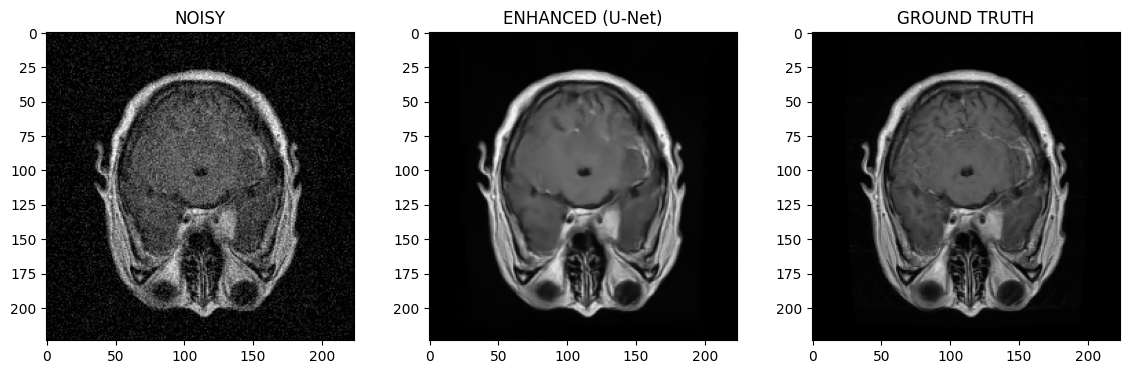

In [ ]:
import matplotlib.pyplot as plt

noisy, clean, names = next(iter(test_loader))

noisy_img = noisy[0].squeeze().cpu().numpy()
clean_img = clean[0].squeeze().cpu().numpy()

with torch.no_grad():
    pred = unet(noisy[0].unsqueeze(0).to(DEVICE))
pred_img = pred.squeeze().cpu().numpy()

plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.imshow(noisy_img, cmap="gray")
plt.title("NOISY")

plt.subplot(1,3,2)
plt.imshow(pred_img, cmap="gray")
plt.title("ENHANCED (U-Net)")

plt.subplot(1,3,3)
plt.imshow(clean_img, cmap="gray")
plt.title("GROUND TRUTH")

plt.show()


In [ ]:
# -------------------Testing Model 2---------------------------#
#--------------------------------------------------------------#
#------------------------DnCNN---------------------------------#
#--------------------------------------------------------------#


In [ ]:
# CELL 1: DnCNN (2D) - lightweight version for MRI denoising
import torch
import torch.nn as nn

class DnCNN(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, depth=17, n_feats=64):
        super().__init__()
        layers = []
        # first layer
        layers.append(nn.Conv2d(in_ch, n_feats, 3, padding=1))
        layers.append(nn.ReLU(inplace=True))
        # middle layers
        for _ in range(depth-2):
            layers.append(nn.Conv2d(n_feats, n_feats, 3, padding=1, bias=False))
            layers.append(nn.BatchNorm2d(n_feats))
            layers.append(nn.ReLU(inplace=True))
        # last layer
        layers.append(nn.Conv2d(n_feats, out_ch, 3, padding=1, bias=False))
        # DnCNN learns the noise residual -> output = input - noise
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        residual = self.net(x)
        return torch.clamp(x - residual, 0.0, 1.0)


In [ ]:
# CELL 2: Training loop for DnCNN
def train_dncnn(model, train_loader, val_loader, epochs=60, lr=5e-5, patience=7):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = torch.cuda.amp.GradScaler()

    best_ssim = -1.0
    no_improve = 0

    for epoch in range(1, epochs+1):
        model.train()
        total_loss = 0.0
        for noisy, clean, _ in train_loader:
            noisy = noisy.to(DEVICE)
            clean = clean.to(DEVICE)

            opt.zero_grad()
            with torch.cuda.amp.autocast():
                pred = model(noisy)
                loss, _, _ = enhancement_loss(pred, clean)

            scaler.scale(loss).backward()
            # -----------------------------
            # GRADIENT CLIPPING (IMPORTANT)
            # -----------------------------
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            scaler.step(opt)
            scaler.update()

            total_loss += loss.item()

        # ---------------- VALIDATION ----------------
        model.eval()
        psnr_val, ssim_val = 0.0, 0.0
        cnt = 0
        with torch.no_grad():
            for noisy, clean, _ in val_loader:
                noisy = noisy.to(DEVICE)
                clean = clean.to(DEVICE)
                pred = model(noisy)
                p, s = compute_metrics(pred, clean)
                psnr_val += p
                ssim_val += s
                cnt += 1
        psnr_val /= max(1, cnt)
        ssim_val /= max(1, cnt)

        print(f"Epoch {epoch}/{epochs} | Loss={total_loss/len(train_loader):.4f} | PSNR={psnr_val:.3f} | SSIM={ssim_val:.4f}")

        # save best
        if ssim_val > best_ssim:
            best_ssim = ssim_val
            no_improve = 0
            # different filename to avoid overwrite
            torch.save(model.state_dict(), SAVE_DIR / "dncnn_best.pth")
            print("✓ Saved BEST DnCNN model")
        else:
            no_improve += 1
        # ---------------- EARLY STOPPING ----------------
        if no_improve >= patience:
            print(f"⛔ Early stopping at epoch {epoch}")
            break

    print("Training finished.")
    return model


In [ ]:
# CELL 3: Instantiate and train (adjust depth/features if you want faster)
dncnn = DnCNN(in_ch=1, depth=17, n_feats=64)   # or depth=10, n_feats=32 to speed up
dncnn = train_dncnn(dncnn, train_loader, val_loader, epochs=60, lr=5e-5, patience=7)


/tmp/ipython-input-76291417.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipython-input-76291417.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/60 | Loss=0.3372 | PSNR=26.075 | SSIM=0.7550
✓ Saved BEST DnCNN model
Epoch 2/60 | Loss=0.1762 | PSNR=29.043 | SSIM=0.8296
✓ Saved BEST DnCNN model
Epoch 3/60 | Loss=0.1633 | PSNR=29.328 | SSIM=0.8324
✓ Saved BEST DnCNN model
Epoch 4/60 | Loss=0.1459 | PSNR=29.913 | SSIM=0.8601
✓ Saved BEST DnCNN model
Epoch 5/60 | Loss=0.1305 | PSNR=30.283 | SSIM=0.8711
✓ Saved BEST DnCNN model
Epoch 6/60 | Loss=0.1283 | PSNR=29.933 | SSIM=0.8683
Epoch 7/60 | Loss=0.1250 | PSNR=30.630 | SSIM=0.8401
Epoch 8/60 | Loss=0.1203 | PSNR=30.716 | SSIM=0.8786
✓ Saved BEST DnCNN model
Epoch 9/60 | Loss=0.1195 | PSNR=30.754 | SSIM=0.8783
Epoch 10/60 | Loss=0.1175 | PSNR=29.974 | SSIM=0.8708
Epoch 11/60 | Loss=0.1142 | PSNR=30.904 | SSIM=0.8781
Epoch 12/60 | Loss=0.1124 | PSNR=31.237 | SSIM=0.8742
Epoch 13/60 | Loss=0.1106 | PSNR=31.195 | SSIM=0.8843
✓ Saved BEST DnCNN model
Epoch 14/60 | Loss=0.1101 | PSNR=30.794 | SSIM=0.8790
Epoch 15/60 | Loss=0.1102 | PSNR=31.392 | SSIM=0.8718
Epoch 16/60 | Loss=0.109

In [ ]:
# CELL 4: Load best and evaluate
dncnn_best = DnCNN(in_ch=1, depth=17, n_feats=64)
dncnn_best.load_state_dict(torch.load(SAVE_DIR / "dncnn_best.pth"))
dncnn_best = dncnn_best.to(DEVICE)
dncnn_best.eval()

psnr_total = 0.0
ssim_total = 0.0
cnt = 0

with torch.no_grad():
    for noisy, clean, _ in test_loader:
        noisy = noisy.to(DEVICE)
        clean = clean.to(DEVICE)
        pred = dncnn_best(noisy)
        p, s = compute_metrics(pred, clean)
        psnr_total += p
        ssim_total += s
        cnt += 1

avg_psnr = psnr_total / cnt
avg_ssim = ssim_total / cnt
print("===== DnCNN ENHANCEMENT TEST RESULTS =====")
print(f"Average PSNR: {avg_psnr:.3f} dB")
print(f"Average SSIM: {avg_ssim:.4f}")


===== DnCNN ENHANCEMENT TEST RESULTS =====
Average PSNR: 31.701 dB
Average SSIM: 0.8919


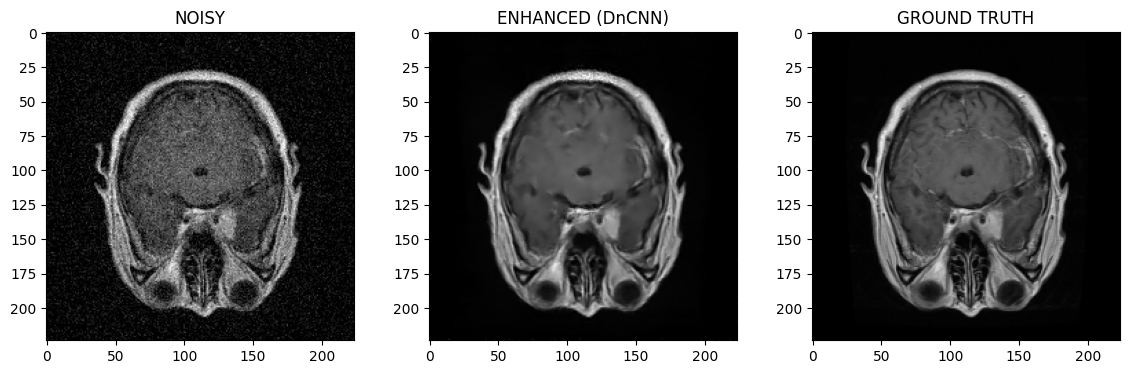

In [ ]:
# CELL 5: visualize one sample (noisy / dncnn / clean)
import matplotlib.pyplot as plt

noisy, clean, names = next(iter(test_loader))
noisy_img = noisy[0].squeeze().cpu().numpy()
clean_img = clean[0].squeeze().cpu().numpy()

with torch.no_grad():
    pred = dncnn_best(noisy[0].unsqueeze(0).to(DEVICE))
pred_img = pred.squeeze().cpu().numpy()

plt.figure(figsize=(14,4))
plt.subplot(1,3,1); plt.imshow(noisy_img, cmap="gray"); plt.title("NOISY")
plt.subplot(1,3,2); plt.imshow(pred_img, cmap="gray"); plt.title("ENHANCED (DnCNN)")
plt.subplot(1,3,3); plt.imshow(clean_img, cmap="gray"); plt.title("GROUND TRUTH")
plt.show()


In [ ]:
# -------------------Testing Model 3---------------------------#
#--------------------------------------------------------------#
#------------------------EDSR---------------------------------#
#--------------------------------------------------------------#


In [ ]:
# CELL 1: EDSR (Baseline ×1 version) adapted for MRI denoising
import torch
import torch.nn as nn

class ResBlock(nn.Module):
    def __init__(self, n_feats, res_scale=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(n_feats, n_feats, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(n_feats, n_feats, 3, padding=1),
        )
        self.res_scale = res_scale

    def forward(self, x):
        return x + self.block(x) * self.res_scale


class EDSR(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, n_feats=64, n_resblocks=8):
        super().__init__()

        # head
        self.head = nn.Conv2d(in_ch, n_feats, 3, padding=1)

        # body: multiple residual blocks
        body = []
        for _ in range(n_resblocks):
            body.append(ResBlock(n_feats))
        body.append(nn.Conv2d(n_feats, n_feats, 3, padding=1))
        self.body = nn.Sequential(*body)

        # tail
        self.tail = nn.Conv2d(n_feats, out_ch, 3, padding=1)

    def forward(self, x):
        head = self.head(x)
        body = self.body(head)
        out = self.tail(head + body)   # residual learning
        return torch.clamp(out, 0.0, 1.0)


In [ ]:
# CELL 2: Training loop for EDSR
def train_edsr(model, train_loader, val_loader, epochs=60, lr=1e-4, patience=7):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = torch.cuda.amp.GradScaler()

    best_ssim = -1
    no_improve = 0

    for epoch in range(1, epochs+1):
        model.train()
        total_loss = 0

        for noisy, clean, _ in train_loader:
            noisy = noisy.to(DEVICE)
            clean = clean.to(DEVICE)

            opt.zero_grad()
            with torch.cuda.amp.autocast():
                pred = model(noisy)
                loss, _, _ = enhancement_loss(pred, clean)

            scaler.scale(loss).backward()

            # -----------------------------
            # GRADIENT CLIPPING (IMPORTANT)
            # -----------------------------

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()

            total_loss += loss.item()

        # ---- Validation ----
        model.eval()
        psnr_val, ssim_val = 0, 0
        cnt = 0

        with torch.no_grad():
            for noisy, clean, _ in val_loader:
                noisy = noisy.to(DEVICE)
                clean = clean.to(DEVICE)
                pred = model(noisy)
                p, s = compute_metrics(pred, clean)
                psnr_val += p
                ssim_val += s
                cnt += 1

        psnr_val /= max(1, cnt)
        ssim_val /= max(1, cnt)

        print(f"Epoch {epoch:02d}/{epochs} | Loss={total_loss/len(train_loader):.4f} | "
              f"PSNR={psnr_val:.3f} | SSIM={ssim_val:.4f}")

        # Save best
        if ssim_val > best_ssim:
            best_ssim = ssim_val
            no_improve = 0
            torch.save(model.state_dict(), SAVE_DIR / "edsr_best.pth")
            print("✓ Saved BEST EDSR model")
        else:
            no_improve += 1

        # ---------------- EARLY STOPPING ----------------

        if no_improve >= patience:
            print(f"⛔ Early stopping at epoch {epoch}")
            break

    print("Training finished.")
    return model


In [ ]:
# CELL 3: Train EDSR
edsr = EDSR(in_ch=1, out_ch=1, n_feats=64, n_resblocks=8)
edsr = train_edsr(edsr, train_loader, val_loader, epochs=60, lr=1e-4, patience=7)


/tmp/ipython-input-1771493758.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipython-input-1771493758.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 01/60 | Loss=0.2232 | PSNR=25.398 | SSIM=0.7394
✓ Saved BEST EDSR model
Epoch 02/60 | Loss=0.1891 | PSNR=29.905 | SSIM=0.8344
✓ Saved BEST EDSR model
Epoch 03/60 | Loss=0.1730 | PSNR=30.414 | SSIM=0.8222
Epoch 04/60 | Loss=0.1477 | PSNR=30.889 | SSIM=0.8343
Epoch 05/60 | Loss=0.1329 | PSNR=30.111 | SSIM=0.8619
✓ Saved BEST EDSR model
Epoch 06/60 | Loss=0.1269 | PSNR=31.641 | SSIM=0.8558
Epoch 07/60 | Loss=0.1183 | PSNR=31.807 | SSIM=0.8742
✓ Saved BEST EDSR model
Epoch 08/60 | Loss=0.1197 | PSNR=31.234 | SSIM=0.8678
Epoch 09/60 | Loss=0.1139 | PSNR=31.852 | SSIM=0.8736
Epoch 10/60 | Loss=0.1134 | PSNR=31.745 | SSIM=0.8725
Epoch 11/60 | Loss=0.1154 | PSNR=31.909 | SSIM=0.8792
✓ Saved BEST EDSR model
Epoch 12/60 | Loss=0.1149 | PSNR=31.980 | SSIM=0.8776


In [ ]:
# CELL 4: Load best EDSR and test
edsr_best = EDSR(in_ch=1, out_ch=1, n_feats=64, n_resblocks=8)
edsr_best.load_state_dict(torch.load(SAVE_DIR / "edsr_best.pth"))
edsr_best = edsr_best.to(DEVICE)
edsr_best.eval()

psnr_total = 0
ssim_total = 0
cnt = 0

with torch.no_grad():
    for noisy, clean, _ in test_loader:
        noisy = noisy.to(DEVICE)
        clean = clean.to(DEVICE)
        pred = edsr_best(noisy)
        p, s = compute_metrics(pred, clean)
        psnr_total += p
        ssim_total += s
        cnt += 1

avg_psnr = psnr_total / cnt
avg_ssim = ssim_total / cnt

print("===== EDSR ENHANCEMENT TEST RESULTS =====")
print(f"Average PSNR: {avg_psnr:.3f} dB")
print(f"Average SSIM: {avg_ssim:.4f}")


===== EDSR ENHANCEMENT TEST RESULTS =====
Average PSNR: 32.469 dB
Average SSIM: 0.8978


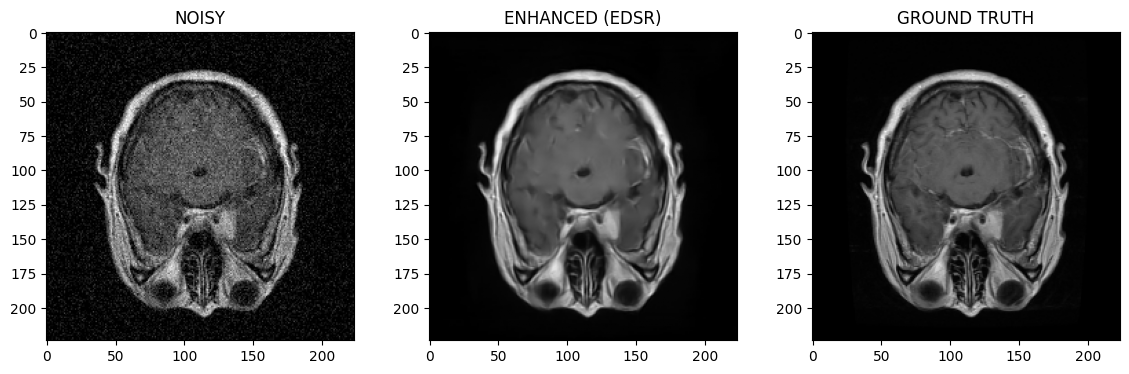

In [ ]:
# CELL 5: visual example
import matplotlib.pyplot as plt

noisy, clean, names = next(iter(test_loader))
noisy_img = noisy[0].squeeze().cpu().numpy()
clean_img = clean[0].squeeze().cpu().numpy()

with torch.no_grad():
    pred = edsr_best(noisy[0].unsqueeze(0).to(DEVICE))
pred_img = pred.squeeze().cpu().numpy()

plt.figure(figsize=(14,4))
plt.subplot(1,3,1); plt.imshow(noisy_img, cmap="gray"); plt.title("NOISY")
plt.subplot(1,3,2); plt.imshow(pred_img, cmap="gray"); plt.title("ENHANCED (EDSR)")
plt.subplot(1,3,3); plt.imshow(clean_img, cmap="gray"); plt.title("GROUND TRUTH")
plt.show()


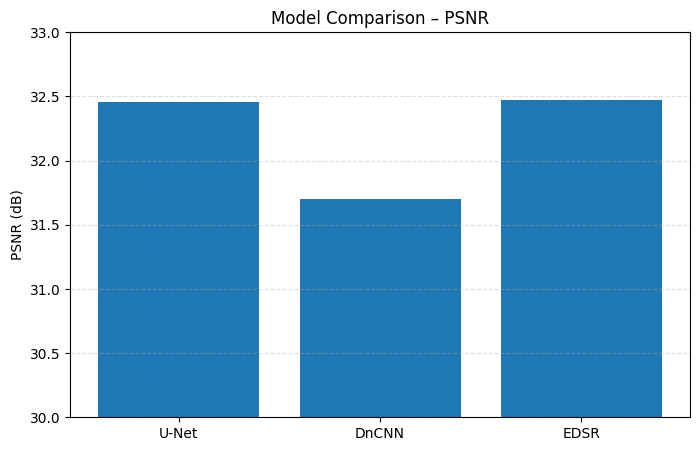

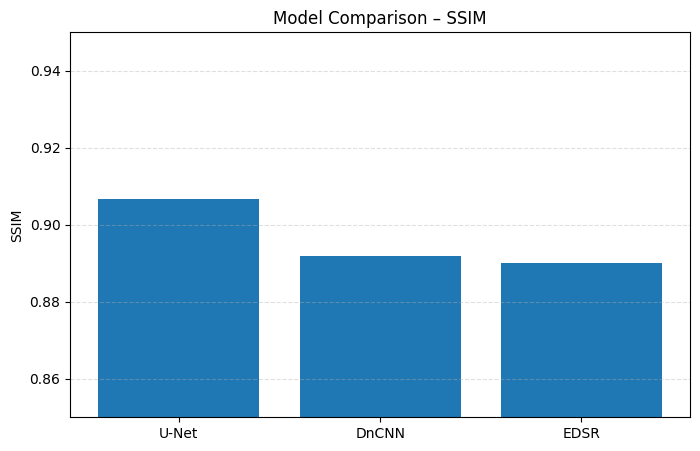


===== MODEL PERFORMANCE TABLE =====

   Model  PSNR (dB)    SSIM
0  U-Net     32.453  0.9066
1  DnCNN     31.701  0.8919
2   EDSR     32.469  0.8900


In [ ]:
#-------------------Model Comparison Code (PSNR + SSIM + Graphs)---------------
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------
# ENTER YOUR MODEL RESULTS HERE
# ------------------------------

model_names = ["U-Net", "DnCNN", "EDSR"]

psnr_scores = [32.453, 31.701, 32.469]     # PSNR values you obtained
ssim_scores = [0.9066, 0.8919, 0.89]     # SSIM values you obtained


# ------------------------------
# PLOT PSNR (Bar Chart)
# ------------------------------
plt.figure(figsize=(8,5))
plt.bar(model_names, psnr_scores)
plt.title("Model Comparison – PSNR")
plt.ylabel("PSNR (dB)")
plt.ylim(30, 33)  # Show only the range 30–33
plt.yticks(np.arange(30, 33.5, 0.5))  # Tick gap of 0.5
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


# ------------------------------
# PLOT SSIM (Bar Chart)
# ------------------------------
plt.figure(figsize=(8,5))
plt.bar(model_names, ssim_scores)
plt.title("Model Comparison – SSIM")
plt.ylabel("SSIM")
plt.ylim(0.85, 0.95)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


# ------------------------------
# COMBINED TABLE (OPTIONAL)
# ------------------------------
import pandas as pd

df = pd.DataFrame({
    "Model": model_names,
    "PSNR (dB)": psnr_scores,
    "SSIM": ssim_scores
})

print("\n===== MODEL PERFORMANCE TABLE =====\n")
print(df)


In [ ]:
#------------------image generation---------------#
#ENHACED ONE

In [ ]:
#------------Create Output Folder Structure-----------------

import os

ENH_OUT = "/content/drive/MyDrive/brain_tumor_project/data/enhanced/unet"

classes = ["1", "2", "3", "no_tumor"]
splits = ["train", "val", "test"]

for split in splits:
    for cls in classes:
        os.makedirs(f"{ENH_OUT}/{split}/{cls}", exist_ok=True)

print("✔ Enhanced dataset directory created.")


✔ Enhanced dataset directory created.


In [ ]:
#-------------------Load Best U-Net Model--------------------
unet = UNetSmall(in_ch=1)
unet.load_state_dict(torch.load(
    "/content/drive/MyDrive/brain_tumor_project/models/enhancement/unet_best.pth",
    map_location=DEVICE
))
unet = unet.to(DEVICE)
unet.eval()

print("✔ U-Net loaded successfully!")


✔ U-Net loaded successfully!


In [ ]:
#----------------------------Function to Enhance and Save Images----------------------
import cv2
import torch
import numpy as np
from tqdm import tqdm

def enhance_and_save(model, loader, split_name):
    for noisy, _, names, classes in tqdm(loader, desc=f"Enhancing {split_name}"):

        noisy = noisy.to(DEVICE)
        with torch.no_grad():
            pred = model(noisy).cpu().numpy()

        for i in range(len(names)):
            img = pred[i, 0]
            img = (img * 255).astype(np.uint8)

            cls = classes[i]  # <-- correct class directly from dataset
            name = names[i]

            save_path = f"{ENH_OUT}/{split_name}/{cls}/{name}"
            cv2.imwrite(save_path, img)



In [ ]:
#-----------------------Run for Train, Val, Test----------------------
enhance_and_save(unet, train_loader, "train")
enhance_and_save(unet, val_loader, "val")
enhance_and_save(unet, test_loader, "test")

print("\n🎉 U-Net Enhanced Dataset Generated Successfully!")


Enhancing test: 100%|██████████| 40/40 [08:14<00:00, 12.36s/it]


🎉 U-Net Enhanced Dataset Generated Successfully!
